In [ ]:
# --- parameters (patch_notebook_params.py) ---
MAX_EPOCHS = 2000
N_SAMPLES = 10           # run_metrics.py forces 50 for generative methods
RESET_TRAINING = False
CUDA_VISIBLE_DEVICES = "0"
METRICS_CSV = "results/metrics.csv"
SKIP_TRAINING = False    # run_metrics.py sets this True: load weights from
                         # the checkpoint directly instead of calling
                         # trainer.fit(), which can silently retrain for the
                         # full schedule if the checkpoint does not cleanly
                         # resume to exactly MAX_EPOCHS.


In [ ]:
# --- epoch heartbeat (patch_notebook_params.py) ---
import pytorch_lightning as _pl

class EpochHeartbeat(_pl.Callback):
    """Prints one clear progress line every `every_n_epochs` epochs, so
    sbatch logs show training progress without the noise of a per-batch
    tqdm progress bar (which doesn't render well once redirected to a
    plain log file).    """

    def __init__(self, every_n_epochs: int = 1):
        self.every_n_epochs = every_n_epochs

    def on_train_epoch_end(self, trainer, pl_module):
        epoch = trainer.current_epoch + 1
        if epoch % self.every_n_epochs != 0 and epoch != trainer.max_epochs:
            return
        parts = []
        for k, v in sorted(trainer.callback_metrics.items()):
            try:
                parts.append(f'{k}={float(v):.4f}')
            except (TypeError, ValueError):
                pass
        print(f'[progress] epoch {epoch}/{trainer.max_epochs} | ' + ' | '.join(parts), flush=True)


# 4DVarNet — SSH Reconstruction with UNet Gradient Model

Version de 4DVarNet où le modèle de gradient (habituellement ConvLSTM) est remplacé par un **UNet conditionné sur le temps du solveur** via un embedding sinusoïdal à la manière des modèles de diffusion.

À chaque itération $k$ du solveur sur $N$ étapes totales, le temps normalisé $t_k = k / (N-1) \in [0, 1]$ est transformé en un vecteur de conditioning injecté dans chaque bloc du UNet (comme le *noise level* dans DDPM).

| Entrée UNet | Shape | Description |
|-------------|-------|-------------|
| $x_k$ | `(B, C, H, W)` | État courant |
| $\nabla_x J(x_k)$ | `(B, C, H, W)` | Gradient du coût variationnel |
| $y_\text{filled}$ | `(B, C, H, W)` | Observations (NaN → 0) |
| $m$ | `(B, C, H, W)` | Masque binaire |
| $t_k$ | scalaire | Temps solveur normalisé → embedding sinusoïdal |

**Sortie** : $\Delta x$ — correction à additionner à $x_k$.

Coût variationnel : $J(x) = \|m \odot x - m \odot y\|^2 + \alpha \|x - x_\text{bg}\|^2$


## 🛠️ Setup

In [1]:
!nvidia-smi


Sat Mar 21 09:37:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 555.42.02              Driver Version: 555.42.02      CUDA Version: 12.5     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     Off |   00000000:4A:00.0 Off |                    0 |
|  0%   35C    P0             75W /  300W |    1941MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = CUDA_VISIBLE_DEVICES

env: CUDA_VISIBLE_DEVICES=2


### Imports

In [3]:
import json
import math
import os
import zipfile
import glob
from dataclasses import asdict, dataclass, field
from typing import Any, Callable, List, Optional, Tuple, Union

import torch
from einops import rearrange
from einops.layers.torch import Rearrange
import pytorch_lightning as pl
from pytorch_lightning import LightningDataModule, LightningModule, Trainer, seed_everything
from pytorch_lightning.callbacks import LearningRateMonitor, ModelCheckpoint
from pytorch_lightning.loggers import TensorBoardLogger
from matplotlib import pyplot as plt
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader
from torchinfo import summary

import sys
sys.path.append('../../..')


## 🧠 Implementation

### DataModule

Norm stats (0.3047108663749711, 0.3879814586804132)


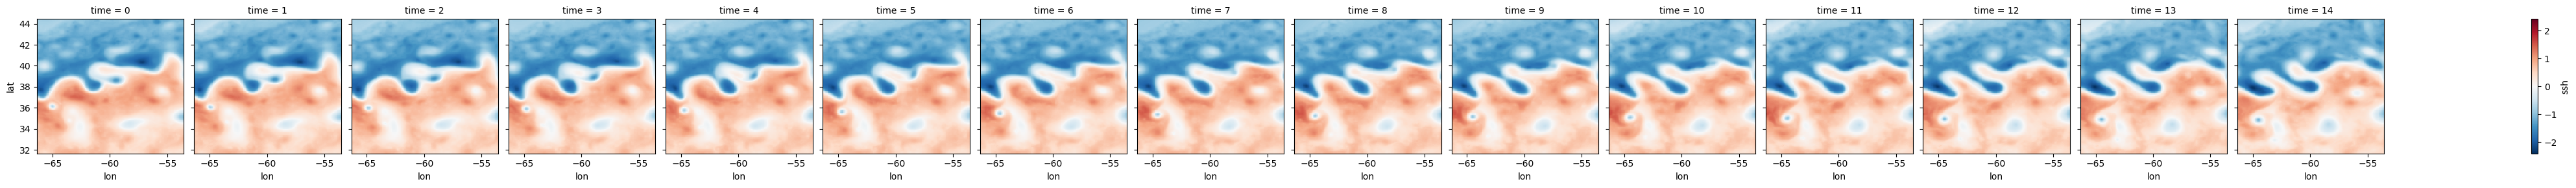

In [4]:
import pyinterp
import pyinterp.fill
import pyinterp.backends.xarray
from src.data_notebook import *

import itertools
import numpy as np
import xarray as xr

lon_min = -66.3
lon_max = -53.5
lat_min = 31.7
lat_max = 44.5

datadir = "../../../data"

TrainingItem = namedtuple('TrainingItem', ['input', 'tgt'])

def remove_nan(da):
    da["lon"] = da.lon.assign_attrs(units="degrees_east")
    da["lat"] = da.lat.assign_attrs(units="degrees_north")
    da.transpose("lon", "lat", "time")[:, :] = pyinterp.fill.gauss_seidel(
        pyinterp.backends.xarray.Grid3D(da)
    )[1]
    return da

def load_altimetry_data(path, obs_from_tgt=False):
    ds = (
        xr.open_dataset(path)
        .load()
        .assign(
            input=lambda ds: ds.nadir_obs,
            tgt=lambda ds: remove_nan(ds.ssh),
        )
    )
    if obs_from_tgt:
        ds = ds.assign(input=ds.tgt.where(np.isfinite(ds.input), np.nan))
    return (
        ds[[*TrainingItem._fields]]
        .transpose("time", "lat", "lon")
        .to_array()
    )

datamodule = BaseDataModule(
    input_da=load_altimetry_data(datadir + "/natl_gf_w_5nadirs_swot.nc"),
    domains={
        'train': {'time': slice('2013-02-24', '2013-09-30')},
        'val':   {'time': slice('2012-12-15', '2013-02-24')},
        'test':  {'time': slice('2012-10-01', '2012-12-20')},
    },
    xrds_kw={
        'patch_dims':    {'time': 15, 'lat': 128, 'lon': 128},
        'strides':       {'time': 1,  'lat': 128, 'lon': 128},
        'domain_limits': dict(lon=slice(lon_min, lon_max),
                              lat=slice(lat_min, lat_max)),
    },
    dl_kw={'batch_size': 2, 'num_workers': 1},
    grad=False,
    resize_factor=2,
)
datamodule.setup()

# Quick sanity plot
xr.Dataset(
    data_vars={'ssh': (('time', 'lat', 'lon'), datamodule.train_ds[0].tgt)},
    coords={
        'time': np.arange(15),
        'lon':  np.arange(lon_min, lon_max, 0.1),
        'lat':  np.arange(lat_min, lat_max, 0.1),
    },
).ssh.plot(col='time', col_wrap=15)


### Modules UNet (blocs réutilisés du notebook de référence)

In [5]:
def GroupNorm(channels: int) -> nn.GroupNorm:
    return nn.GroupNorm(num_groups=min(32, channels // 4), num_channels=channels)


class SelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.dropout = dropout
        self.qkv_projection = nn.Sequential(
            GroupNorm(in_channels),
            nn.Conv2d(in_channels, 3 * in_channels, kernel_size=1, bias=False),
            Rearrange("b (i h d) x y -> i b h (x y) d", i=3, h=n_heads),
        )
        self.output_projection = nn.Sequential(
            Rearrange("b h l d -> b l (h d)"),
            nn.Linear(in_channels, out_channels, bias=False),
            Rearrange("b l d -> b d l"),
            GroupNorm(out_channels),
            nn.Dropout1d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor) -> Tensor:
        q, k, v = self.qkv_projection(x).unbind(dim=0)
        output = F.scaled_dot_product_attention(
            q, k, v, dropout_p=self.dropout if self.training else 0.0, is_causal=False
        )
        output = self.output_projection(output)
        output = rearrange(output, "b c (x y) -> b c x y", x=x.shape[-2], y=x.shape[-1])
        return output + self.residual_projection(x)


class UNetBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 noise_level_channels: int, dropout: float = 0.3) -> None:
        super().__init__()
        self.input_projection = nn.Sequential(
            GroupNorm(in_channels), nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.noise_level_projection = nn.Sequential(
            nn.SiLU(),
            nn.Conv2d(noise_level_channels, out_channels, kernel_size=1),
        )
        self.output_projection = nn.Sequential(
            GroupNorm(out_channels), nn.SiLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding="same"),
            nn.Dropout2d(dropout),
        )
        self.residual_projection = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: Tensor, cond: Tensor) -> Tensor:
        h = self.input_projection(x)
        h = h + self.noise_level_projection(cond)
        return self.output_projection(h) + self.residual_projection(x)


class UNetBlockWithSelfAttention(nn.Module):
    def __init__(self, in_channels: int, out_channels: int,
                 noise_level_channels: int, n_heads: int = 8, dropout: float = 0.3) -> None:
        super().__init__()
        self.unet_block = UNetBlock(in_channels, out_channels, noise_level_channels, dropout)
        self.self_attention = SelfAttention(out_channels, out_channels, n_heads, dropout)

    def forward(self, x: Tensor, cond: Tensor) -> Tensor:
        return self.self_attention(self.unet_block(x, cond))


class Downsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            Rearrange("b c (h ph) (w pw) -> b (c ph pw) h w", ph=2, pw=2),
            nn.Conv2d(4 * channels, channels, kernel_size=1),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


class Upsample(nn.Module):
    def __init__(self, channels: int) -> None:
        super().__init__()
        self.projection = nn.Sequential(
            nn.Upsample(scale_factor=2.0, mode="nearest"),
            nn.Conv2d(channels, channels, kernel_size=3, padding="same"),
        )
    def forward(self, x: Tensor) -> Tensor:
        return self.projection(x)


### Embedding temporel sinusoïdal (style modèles de diffusion)

Le temps du solveur $t_k = k / (N-1) \in [0, 1]$ est converti en un vecteur de conditioning `(B, D, 1, 1)` via :

$$\text{emb}(t)_{2i}   = \sin\!\left(t \cdot \omega_i\right), \quad
  \text{emb}(t)_{2i+1} = \cos\!\left(t \cdot \omega_i\right)$$

avec $\omega_i = 10000^{-2i/D}$ (comme dans DDPM / Transformers), suivi d'un petit MLP `D → 4D → D`.

In [17]:
class SinusoidalTimeEmbedding(nn.Module):
    """
    Convertit un scalaire t ∈ [0, 1] en un vecteur de conditioning (B, out_dim, 1, 1).

    Architecture identique aux modèles de diffusion DDPM :
        1. Encodage sinusoïdal en dim dimensions (sin/cos à fréquences log-espacées)
        2. MLP : dim → 4*dim → out_dim  (activations SiLU)
        3. Reshape → (B, out_dim, 1, 1) pour être compatible avec Conv2d
    """
    def __init__(self, dim: int = 128, out_dim: Optional[int] = None) -> None:
        super().__init__()
        out_dim = out_dim or dim
        half = dim // 2
        # fréquences log-espacées fixes (non-apprises), comme dans DDPM
        freqs = torch.exp(
            -math.log(10000) * torch.arange(half, dtype=torch.float32) / (half - 1)
        )
        self.register_buffer("freqs", freqs)          # (half,)

        self.mlp = nn.Sequential(
            nn.Linear(dim, 4 * dim),
            nn.SiLU(),
            nn.Linear(4 * dim, out_dim),
        )

    def forward(self, t: Tensor) -> Tensor:
        """
        Parameters
        ----------
        t : (B,) ou scalaire — temps solveur normalisé ∈ [0, 1]

        Returns
        -------
        emb : (B, out_dim, 1, 1)
        """
        if t.dim() == 0:
            t = t.unsqueeze(0)                        # (1,)
        t = t.float()
        # (B, half)
        angles = t[:, None] * self.freqs[None, :]
        # concaténation sin / cos → (B, dim)
        emb = torch.cat([angles.sin(), angles.cos()], dim=-1)
        # Cast to match MLP weights dtype (e.g. bfloat16 if model is in half precision)
        emb = emb.to(dtype=next(self.mlp.parameters()).dtype)
        emb = self.mlp(emb)                           # (B, out_dim)
        return emb[:, :, None, None]                  # (B, out_dim, 1, 1)


### UNet comme modèle de gradient 4DVarNet

Le UNet remplace le ConvLSTM du notebook de référence.

À chaque itération $k$ du solveur, il reçoit en entrée :
- $x_k$ — état courant  `(B, C, H, W)`
- $\nabla_x J(x_k)$ — gradient du coût variationnel  `(B, C, H, W)`

soit **2C canaux au total**, et produit une correction $\Delta x$ de taille `(B, C, H, W)`.

$y$ et $m$ ne sont **pas** passés au UNet : le gradient $\nabla_x J$ les encode déjà implicitement :

$$\nabla_x J = 2\,m \odot (m \odot x - m \odot y) + 2\alpha\,(x - x_\text{bg})$$

Le temps $t_k \in [0,1]$ est injecté via l'embedding sinusoïdal comme conditioning `(B, D, 1, 1)` dans chaque `UNetBlock`.

In [18]:
@dataclass
class GradSolverUNetConfig:
    channels: int = 15                                    # C — pas de temps SSH
    time_emb_dim: int = 128                               # D — dim embedding temporel
    n_heads: int = 8
    top_blocks_channels: Tuple[int, ...] = (56, 56)
    top_blocks_n_blocks_per_resolution: Tuple[int, ...] = (2, 2)
    top_blocks_has_resampling: Tuple[bool, ...] = (True, True)
    top_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)
    mid_blocks_channels: Tuple[int, ...] = (128, 256)
    mid_blocks_n_blocks_per_resolution: Tuple[int, ...] = (4, 4)
    mid_blocks_has_resampling: Tuple[bool, ...] = (True, False)
    mid_blocks_dropout: Tuple[float, ...] = (0.0, 0.0)


class GradSolverUNet(nn.Module):
    """
    UNet utilisé comme modèle de gradient dans le solveur 4DVarNet.

    Remplace ConvLstmGradModel. Contrairement au LSTM, ce module est
    **stateless** — pas de hidden state entre les itérations du solveur ;
    c'est le temps t_k (embedding sinusoïdal) qui porte l'information
    sur l'étape courante.

    forward(x, grad_j, t) -> Δx  (B, C, H, W)

    Entrée : concaténation [x | grad_j_normalisé]  →  2C canaux
    (y et mask ne sont pas passés : ils sont implicitement encodés dans grad_j
     via ∇J = 2·m⊙(m⊙x - m⊙y) + 2α(x - x_bg))
    Conditioning : SinusoidalTimeEmbedding(t)  →  (B, D, 1, 1)
    """
    def __init__(self, config: GradSolverUNetConfig) -> None:
        super().__init__()
        self.config = config
        C = config.channels
        D = config.top_blocks_channels[0]
        EMB = config.time_emb_dim

        # Embedding temporel sinusoïdal → (B, EMB, 1, 1)
        self.time_embedding = SinusoidalTimeEmbedding(dim=EMB, out_dim=EMB)

        # Projection d'entrée : 2C canaux → D
        self.input_projection = nn.Conv2d(2 * C, D, kernel_size=3, padding="same")

        self.top_encoder_blocks = self._make_encoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout,
            self._make_top_block,
        )
        self.mid_encoder_blocks = self._make_encoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout,
            self._make_mid_block,
        )
        self.mid_decoder_blocks = self._make_decoder_blocks(
            config.mid_blocks_channels + config.mid_blocks_channels[-1:],
            config.mid_blocks_n_blocks_per_resolution,
            config.mid_blocks_has_resampling,
            config.mid_blocks_dropout,
            self._make_mid_block,
        )
        self.top_decoder_blocks = self._make_decoder_blocks(
            config.top_blocks_channels + config.mid_blocks_channels[:1],
            config.top_blocks_n_blocks_per_resolution,
            config.top_blocks_has_resampling,
            config.top_blocks_dropout,
            self._make_top_block,
        )
        # Sortie : D → C (correction Δx)
        self.output_projection = nn.Conv2d(D, C, kernel_size=3, padding="same")

    # ------------------------------------------------------------------ forward
    def forward(
        self,
        x: Tensor,       # (B, C, H, W)  état courant
        grad_j: Tensor,  # (B, C, H, W)  gradient ∇J(x)
        t: Tensor,       # (B,) ou scalaire  temps normalisé ∈ [0,1]
    ) -> Tensor:
        """Retourne Δx de shape (B, C, H, W)."""
        # Normalisation du gradient (comme ConvLstmGradModel)
        grad_norm = (grad_j ** 2).mean().sqrt().clamp(min=1e-8)
        grad_j_n  = grad_j / grad_norm

        # Concaténation [x | grad_j_norm] → (B, 2C, H, W)
        h = self.input_projection(torch.cat([x, grad_j_n], dim=1))

        # Conditioning temporel → (B, EMB, 1, 1)
        cond = self.time_embedding(t)

        # Encodeur top
        top_skips = []
        for block in self.top_encoder_blocks:
            if isinstance(block, UNetBlock):
                h = block(h, cond)
                top_skips.append(h)
            else:
                h = block(h)

        # Encodeur mid
        mid_skips = []
        for block in self.mid_encoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = block(h, cond)
                mid_skips.append(h)
            else:
                h = block(h)

        # Décodeur mid
        for block in self.mid_decoder_blocks:
            if isinstance(block, UNetBlockWithSelfAttention):
                h = torch.cat((h, mid_skips.pop()), dim=1)
                h = block(h, cond)
            else:
                h = block(h)

        # Décodeur top
        for block in self.top_decoder_blocks:
            if isinstance(block, UNetBlock):
                h = torch.cat((h, top_skips.pop()), dim=1)
                h = block(h, cond)
            else:
                h = block(h)

        return self.output_projection(h)   # (B, C, H, W)

    # ------------------------------------------------------------------ helpers
    def _make_encoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (ic, oc) in enumerate(zip(channels[:-1], channels[1:])):
            for _ in range(n_blocks[idx]):
                blocks.append(block_fn(ic, oc, dropout[idx]))
                ic = oc
            if has_resampling[idx]:
                blocks.append(Downsample(oc))
        return blocks

    def _make_decoder_blocks(self, channels, n_blocks, has_resampling, dropout, block_fn):
        blocks = nn.ModuleList()
        for idx, (oc, ic) in enumerate(list(zip(channels[:-1], channels[1:]))[::-1]):
            if has_resampling[::-1][idx]:
                blocks.append(Upsample(ic))
            inner = []
            for _ in range(n_blocks[::-1][idx]):
                inner.append(block_fn(ic * 2, oc, dropout[::-1][idx]))
                oc = ic
            blocks.extend(inner[::-1])
        return blocks

    def _make_top_block(self, ic, oc, dropout):
        return UNetBlock(ic, oc, self.config.time_emb_dim, dropout)

    def _make_mid_block(self, ic, oc, dropout):
        return UNetBlockWithSelfAttention(
            ic, oc, self.config.time_emb_dim, self.config.n_heads, dropout
        )

    # ------------------------------------------------------------------ I/O
    def save_pretrained(self, pretrained_path: str) -> None:
        os.makedirs(pretrained_path, exist_ok=True)
        with open(os.path.join(pretrained_path, "config_4dvarnet_unet.json"), mode="w") as f:
            json.dump(asdict(self.config), f)
        torch.save(self.state_dict(), os.path.join(pretrained_path, "model_4dvarnet_unet.pt"))

    @classmethod
    def from_pretrained(cls, pretrained_path: str) -> "GradSolverUNet":
        with open(os.path.join(pretrained_path, "config_4dvarnet_unet.json"), mode="r") as f:
            config_dict = json.load(f)
        config = GradSolverUNetConfig(**config_dict)
        model = cls(config)
        state_dict = torch.load(
            os.path.join(pretrained_path, "model_4dvarnet_unet.pt"),
            map_location="cpu",
        )
        model.load_state_dict(state_dict)
        return model


# Sanity check — summary
C = GradSolverUNetConfig().channels
summary(
    GradSolverUNet(GradSolverUNetConfig()),
    input_data=[
        torch.zeros(1, C, 128, 128),   # x
        torch.zeros(1, C, 128, 128),   # grad_j
        torch.tensor([0.5]),            # t
    ],
)


Layer (type:depth-idx)                        Output Shape              Param #
GradSolverUNet                                [1, 15, 128, 128]         --
├─Conv2d: 1-1                                 [1, 56, 128, 128]         15,176
├─SinusoidalTimeEmbedding: 1-2                [1, 128, 1, 1]            --
│    └─Sequential: 2-1                        [1, 128]                  --
│    │    └─Linear: 3-1                       [1, 512]                  66,048
│    │    └─SiLU: 3-2                         [1, 512]                  --
│    │    └─Linear: 3-3                       [1, 128]                  65,664
├─ModuleList: 1-3                             --                        --
│    └─UNetBlock: 2-2                         [1, 56, 128, 128]         --
│    │    └─Sequential: 3-4                   [1, 56, 128, 128]         28,392
│    │    └─Sequential: 3-5                   [1, 56, 1, 1]             7,224
│    │    └─Sequential: 3-6                   [1, 56, 128, 128]         28,3

### Opérateur d'observation & coût variationnel

Coût variationnel : $J(x) = \underbrace{\|m \odot (x - y)\|^2}_{\text{obs}} + \alpha \underbrace{\|x - x_\text{bg}\|^2}_{\text{bg}}$

Gradient analytique :

$$\nabla_x J(x) = 2\, m \odot (m \odot x - m \odot y) + 2\alpha\,(x - x_\text{bg})$$

On utilise `torch.autograd.grad` pour garder les graphes de calcul compatibles avec la backpropagation à travers le solveur.

In [8]:
class ObsCost(nn.Module):
    """
    Coût d'observation : J_obs(x) = || m ⊙ x - m ⊙ y ||²
    Identique à BaseObsCost du notebook de référence.
    """
    def __init__(self, w: float = 1.0) -> None:
        super().__init__()
        self.w = w

    def forward(self, state: Tensor, y_filled: Tensor, mask: Tensor) -> Tensor:
        return self.w * F.mse_loss(state * mask, y_filled * mask)


class BilinAEPriorCost(nn.Module):
    """
    Prior bilinéaire auto-encodeur — identique au notebook de référence.
    J_prior(x) = || x - AE(x) ||²
    """
    def __init__(self, dim_in: int, dim_hidden: int,
                 kernel_size: int = 3, downsamp: Optional[int] = None,
                 bilin_quad: bool = True) -> None:
        super().__init__()
        self.bilin_quad = bilin_quad
        self.conv_in = nn.Conv2d(dim_in, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.conv_hidden = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_1  = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_21 = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.bilin_22 = nn.Conv2d(dim_hidden, dim_hidden, kernel_size, padding=kernel_size // 2)
        self.conv_out = nn.Conv2d(2 * dim_hidden, dim_in, kernel_size, padding=kernel_size // 2)
        self.down = nn.AvgPool2d(downsamp) if downsamp else nn.Identity()
        self.up   = nn.UpsamplingBilinear2d(scale_factor=downsamp) if downsamp else nn.Identity()

    def forward_ae(self, x: Tensor) -> Tensor:
        x = self.down(x)
        x = self.conv_hidden(F.relu(self.conv_in(x)))
        nonlin = self.bilin_21(x) ** 2 if self.bilin_quad else self.bilin_21(x) * self.bilin_22(x)
        x = self.conv_out(torch.cat([self.bilin_1(x), nonlin], dim=1))
        return self.up(x)

    def forward(self, state: Tensor) -> Tensor:
        return F.mse_loss(state, self.forward_ae(state))


def compute_grad_j(
    state: Tensor,
    y_filled: Tensor,
    mask: Tensor,
    obs_cost: ObsCost,
    prior_cost: BilinAEPriorCost,
    alpha: float = 1.0,
) -> Tensor:
    """
    Calcule ∇_x J(x) via autograd, avec le graphe de calcul pour la backprop.
    J(x) = J_obs(x) + alpha * J_prior(x)
    """
    x = state.requires_grad_(True)
    J = obs_cost(x, y_filled, mask) + alpha * prior_cost(x)
    grad = torch.autograd.grad(J, x, create_graph=True)[0]
    return grad


### Solveur 4DVarNet avec UNet

À chaque itération $k \in [0, N-1]$ :

$$x_{k+1} = x_k - \underbrace{\text{UNet}\!\left(x_k,\; \nabla_x J(x_k),\; \tfrac{k}{N-1}\right)}_{\Delta x_k}$$

Initialisation : $x_0 = y_\text{filled}$

La supervision intermédiaire (poids croissant avec $k$) stabilise le début de l'entraînement.

In [9]:
class Solver4DVarUNet(nn.Module):
    """
    Solveur 4DVarNet avec UNet comme modèle de gradient.

    Itère N_solver fois :
        x_{k+1} = x_k - UNet(x_k, ∇J(x_k), t_k)
    avec t_k = k / (N_solver - 1) ∈ [0, 1].

    Paramètres
    ----------
    grad_model   : GradSolverUNet
    obs_cost     : ObsCost
    prior_cost   : BilinAEPriorCost
    n_solver     : nombre d'itérations du solveur (ex. 15)
    alpha_prior  : poids du terme prior dans J
    """
    def __init__(
        self,
        grad_model:  GradSolverUNet,
        obs_cost:    ObsCost,
        prior_cost:  BilinAEPriorCost,
        n_solver:    int   = 15,
        alpha_prior: float = 0.2,
    ) -> None:
        super().__init__()
        self.grad_model  = grad_model
        self.obs_cost    = obs_cost
        self.prior_cost  = prior_cost
        self.n_solver    = n_solver
        self.alpha_prior = alpha_prior

    def forward(
        self,
        y_filled: Tensor,   # (B, C, H, W)
        mask:     Tensor,   # (B, C, H, W)
        return_all_iterates: bool = False,
    ) -> Union[Tensor, List[Tensor]]:
        """
        Retourne x_N (ou la liste [x_0, ..., x_N] si return_all_iterates=True).
        """
        B, C, H, W = y_filled.shape
        device = y_filled.device
        dtype  = y_filled.dtype

        # Initialisation x_0 = y_filled
        x = y_filled.clone()

        iterates = [x] if return_all_iterates else None

        with torch.set_grad_enabled(True):
            for k in range(self.n_solver):
                # Temps normalisé t_k ∈ [0, 1] — (B,)
                t_k = torch.full((B,), k / max(self.n_solver - 1, 1),
                                 device=device, dtype=dtype)

                # ∇J(x_k)  — contient implicitement y et mask via J_obs
                grad_j = compute_grad_j(
                    x, y_filled, mask,
                    self.obs_cost, self.prior_cost, self.alpha_prior,
                )

                # Correction UNet : entre uniquement x et ∇J
                dx = self.grad_model(x, grad_j, t_k)

                # Update : x_{k+1} = x_k - Δx
                x = x - dx

                if not self.training:
                    x = x.detach().requires_grad_(True)

                if return_all_iterates:
                    iterates.append(x)

        return iterates if return_all_iterates else x


### LightningModule — Lit4DVarUNet

In [10]:
@dataclass
class Lit4DVarUNetConfig:
    lr: float = 1e-4
    betas: Tuple[float, float] = (0.9, 0.995)
    lr_scheduler_start_factor: float = 1e-5
    lr_scheduler_iters: int = 10_000
    # Supervision intermédiaire : poids sur les itérées intermédiaires
    # w_k ∝ k  (plus on est avancé, plus on pèse lourd)
    intermediate_supervision: bool = True


class Lit4DVarUNet(LightningModule):
    """
    Lightning wrapper pour 4DVarNet avec UNet gradient model.

    training_step :
        1. Construit y_filled et mask depuis batch.input
        2. Exécute le solveur → [x_0, ..., x_N] (supervision intermédiaire)
           ou x_N seul
        3. Loss = MSE(x_N, tgt)
           + supervision intermédiaire pondérée (poids croissant)

    validation_step : MSE + RMSE sur x_N uniquement.
    """
    def __init__(
        self,
        solver: Solver4DVarUNet,
        config: Lit4DVarUNetConfig = Lit4DVarUNetConfig(),
    ) -> None:
        super().__init__()
        self.solver = solver
        self.config = config

    # ------------------------------------------------------------------ helpers
    @staticmethod
    def _prepare_inputs(y: Tensor) -> Tuple[Tensor, Tensor]:
        mask     = y.isfinite().to(y.dtype)
        y_filled = y.nan_to_num(0.0)
        return y_filled, mask

    # ------------------------------------------------------------------ steps
    def training_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        y_filled, mask = self._prepare_inputs(batch.input)
        tgt = batch.tgt

        if self.config.intermediate_supervision:
            iterates = self.solver(y_filled, mask, return_all_iterates=True)
            N = len(iterates) - 1   # nombre de pas (= n_solver)
            # Poids croissants : w_k = (k+1) / sum(1..N)
            weights = torch.arange(1, N + 2, dtype=tgt.dtype, device=tgt.device)
            weights = weights / weights.sum()
            loss = sum(
                w * F.mse_loss(xk, tgt)
                for xk, w in zip(iterates, weights)
            )
        else:
            x_final = self.solver(y_filled, mask)
            loss = F.mse_loss(x_final, tgt)

        self.log("train_loss", loss, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx: int):
        if isinstance(batch, list):
            batch = batch[0]

        y_filled, mask = self._prepare_inputs(batch.input)
        x_final = self.solver(y_filled, mask)
        loss = F.mse_loss(x_final, batch.tgt)
        rmse = loss.sqrt()

        self.log_dict({"val_loss": loss, "val_rmse": rmse}, prog_bar=True)
        return loss

    # ------------------------------------------------------------------ optim
    def configure_optimizers(self):
        opt = torch.optim.Adam(
            self.parameters(),
            lr=self.config.lr,
            betas=self.config.betas,
        )
        sched = torch.optim.lr_scheduler.LinearLR(
            opt,
            start_factor=self.config.lr_scheduler_start_factor,
            end_factor=1.0,
            total_iters=self.config.lr_scheduler_iters,
        )
        return [opt], [{"scheduler": sched, "interval": "step"}]


## 🚀 Training

In [11]:
def is_valid_checkpoint(path: str) -> bool:
    try:
        import zipfile
        with zipfile.ZipFile(path, 'r') as zf:
            zf.testzip()
        return True
    except Exception:
        return False


def find_best_valid_checkpoint(ckpt_dir: str) -> Optional[str]:
    if not os.path.isdir(ckpt_dir):
        return None
    last_ckpt = os.path.join(ckpt_dir, "last.ckpt")
    if os.path.exists(last_ckpt) and is_valid_checkpoint(last_ckpt):
        print(f"✅ Checkpoint valide : {last_ckpt}")
        return last_ckpt
    all_ckpts = sorted(
        [p for p in glob.glob(os.path.join(ckpt_dir, "*.ckpt"))
         if "last" not in os.path.basename(p)],
        key=lambda p: float(p.split("val_loss=")[-1].replace(".ckpt", ""))
        if "val_loss=" in p else float("inf"),
    )
    for ckpt_path in all_ckpts:
        if is_valid_checkpoint(ckpt_path):
            print(f"✅ Checkpoint valide : {ckpt_path}")
            return ckpt_path
    print("❌ Aucun checkpoint valide. Démarrage depuis zéro.")
    return None


@dataclass
class TrainingConfig:
    unet_config:  GradSolverUNetConfig
    lit_config:   Lit4DVarUNetConfig
    trainer:      Trainer
    n_solver:     int   = 15
    alpha_prior:  float = 0.2
    prior_dim_hidden: int = 64
    seed:         int   = 42
    log_dir:      str   = "logs_4dvarnet_unet"
    log_version:  str   = "v0"
    resume_ckpt_path: Optional[str] = None
    reload:       bool  = False

    @property
    def run_dir(self) -> str:
        return os.path.join(self.log_dir, self.log_version)

    @property
    def model_ckpt_path(self) -> str:
        return os.path.join(self.run_dir, "best_model")

    @property
    def lightning_ckpt_dir(self) -> str:
        return os.path.join(self.run_dir, "checkpoints")


def run_training(config: TrainingConfig) -> None:
    seed_everything(config.seed)

    C = config.unet_config.channels

    if not config.reload:
        grad_model  = GradSolverUNet(config.unet_config)
        obs_cost    = ObsCost(w=1.0)
        prior_cost  = BilinAEPriorCost(dim_in=C, dim_hidden=config.prior_dim_hidden,
                                       bilin_quad=False, downsamp=2)
        solver = Solver4DVarUNet(
            grad_model=grad_model,
            obs_cost=obs_cost,
            prior_cost=prior_cost,
            n_solver=config.n_solver,
            alpha_prior=config.alpha_prior,
        )
    else:
        grad_model = GradSolverUNet.from_pretrained(config.model_ckpt_path)
        obs_cost   = ObsCost(w=1.0)
        prior_cost = BilinAEPriorCost(dim_in=C, dim_hidden=config.prior_dim_hidden,
                                      bilin_quad=False, downsamp=2)
        solver = Solver4DVarUNet(
            grad_model=grad_model,
            obs_cost=obs_cost,
            prior_cost=prior_cost,
            n_solver=config.n_solver,
            alpha_prior=config.alpha_prior,
        )

    lit = Lit4DVarUNet(solver, config.lit_config)

    config.trainer.callbacks.append(EpochHeartbeat(every_n_epochs=1))
    if SKIP_TRAINING:
        if config.resume_ckpt_path is None:
            raise RuntimeError(
                f"SKIP_TRAINING=True but no checkpoint found in {config.lightning_ckpt_dir} -- "
                "run training first (submit_train.sbatch) before computing metrics."
            )
        print(f'[TRAINING] SKIP_TRAINING=True -- loading weights from {config.resume_ckpt_path} directly (trainer.fit() not called)', flush=True)
        _ckpt_state = torch.load(config.resume_ckpt_path, map_location='cpu')
        lit.load_state_dict(_ckpt_state['state_dict'])
    else:
        print(f'[TRAINING] resume_ckpt={config.resume_ckpt_path!r} | MAX_EPOCHS={MAX_EPOCHS}', flush=True)
        config.trainer.fit(lit, datamodule, ckpt_path=config.resume_ckpt_path)

    lit.solver.grad_model.save_pretrained(config.model_ckpt_path)
    print(f"✅ Model saved to: {config.model_ckpt_path}")


### Run Training

In [12]:
LOG_DIR     = "logs_4dvarnet_unet"
CKPT_DIR    = os.path.join(LOG_DIR, "checkpoints")
resume_ckpt = find_best_valid_checkpoint(CKPT_DIR)

training_config = TrainingConfig(
    unet_config=GradSolverUNetConfig(),
    lit_config=Lit4DVarUNetConfig(
        lr_scheduler_iters=1000,
        intermediate_supervision=True,
    ),
    n_solver=15,
    alpha_prior=0.2,
    prior_dim_hidden=64,
    log_dir=LOG_DIR,
    log_version="",
    trainer=Trainer(enable_progress_bar=False, 
        accelerator="gpu",
        max_epochs=MAX_EPOCHS,
        accumulate_grad_batches=4,
        precision="16-mixed",
        log_every_n_steps=1,
        logger=TensorBoardLogger(".", name=LOG_DIR, version=""),
        callbacks=[
            LearningRateMonitor(logging_interval="step"),
            ModelCheckpoint(
                dirpath=CKPT_DIR,
                monitor="val_loss",
                save_top_k=3,
                save_last=True,
                filename="{epoch:03d}-{step}-{val_loss:.4f}",
            ),
        ],
    ),
    resume_ckpt_path=resume_ckpt,  # was commented out -- training always restarted from scratch
)
run_training(training_config)


Using 16bit Automatic Mixed Precision (AMP)
/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42
/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/plugins/precision/amp.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
Global seed set to 42


You are using a CUDA device ('NVIDIA A40') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name   | Type            | Params
-------------------------------------------
0 | solver | Solver4DVarUNet | 32.3 M
-------------------------------------------
32.3 M    Trainable params
0         Non-trainable params
32.3 M    Total params
129.221   Total estimated model params size (MB)
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [2]

  | Name   | Type            | Params
-------------------------------------------
0 | solver | Solver4DVarUNet | 32.3 M
-------------------------------------------
32.3 M    Trainable params
0         Non-trainable params
32.3 M    Total params
129.221   Total estimate

Sanity Checking: 0it [00:00, ?it/s]

/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, val_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 64 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:442: PossibleUserWarning: The dataloader, train_dataloader, does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` (try 64 which is the number of cpus on this machine) in the `DataLoader` init to improve performance.
  rank_zero_warn(
/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/connectors/data_connector.p

Training: 0it [00:00, ?it/s]

...

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

Validation: 0it [00:00, ?it/s]

/Odyssey/private/m19beauc/conda/envs/4dvarnet-starter/lib/python3.12/site-packages/pytorch_lightning/trainer/call.py:53: UserWarning: Detected KeyboardInterrupt, attempting graceful shutdown...
  rank_zero_warn("Detected KeyboardInterrupt, attempting graceful shutdown...")


✅ Model saved to: logs_4dvarnet_unet/v0/best_model


## 🔍 Évaluation & Visualisation

### Chargement du checkpoint

In [19]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
dtype  = torch.bfloat16 if torch.cuda.is_available() else torch.float32

MODEL_PATH = os.path.join("logs_4dvarnet_unet", "best_model")

C = GradSolverUNetConfig().channels
grad_model = GradSolverUNet.from_pretrained(MODEL_PATH).eval().to(device=device, dtype=dtype)
obs_cost   = ObsCost(w=1.0).to(device=device, dtype=dtype)
prior_cost = BilinAEPriorCost(dim_in=C, dim_hidden=64, bilin_quad=False, downsamp=2).to(device=device, dtype=dtype)

solver = Solver4DVarUNet(
    grad_model=grad_model,
    obs_cost=obs_cost,
    prior_cost=prior_cost,
    n_solver=15,
    alpha_prior=0.2,
).eval().to(device=device, dtype=dtype)


### Inférence sur un batch test

Global seed set to 42


RMSE (test batch, itéré final) : 0.5820
Observations y (NaN → 0) :


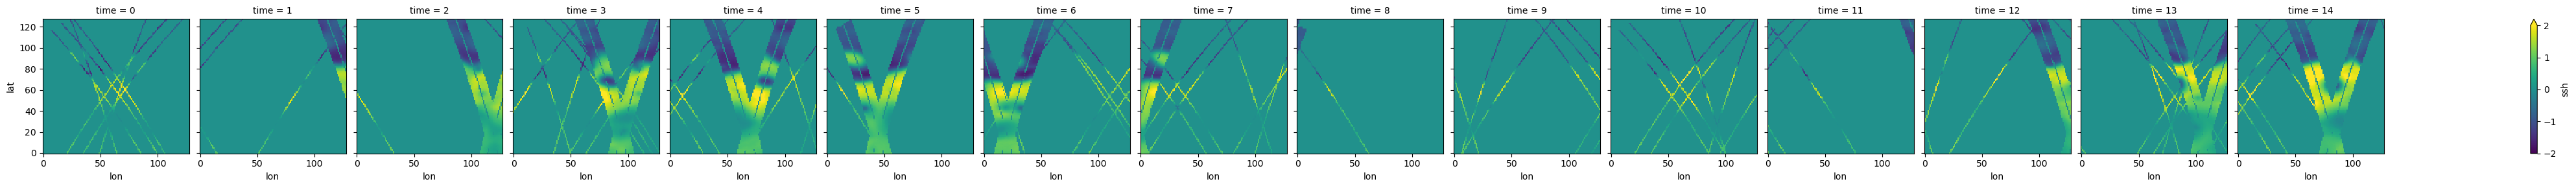

Reconstruction 4DVarNet x_hat :


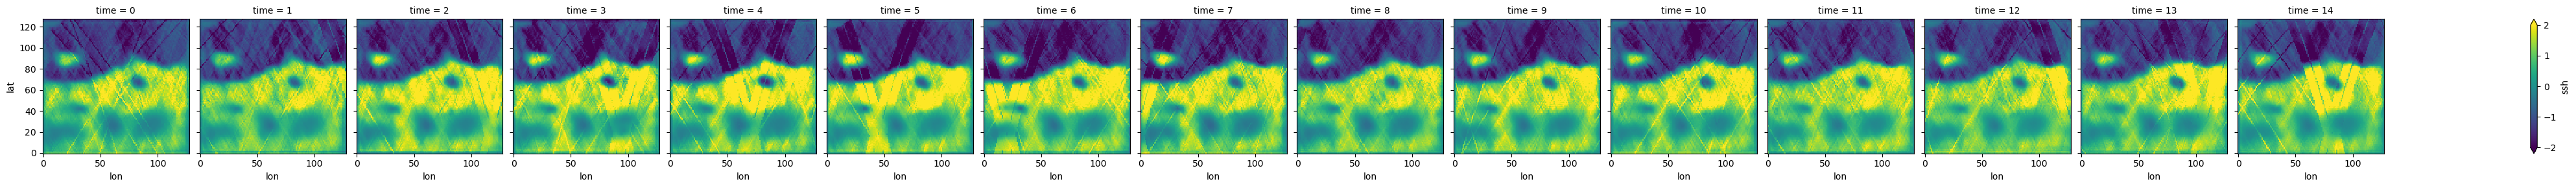

Vérité terrain x :


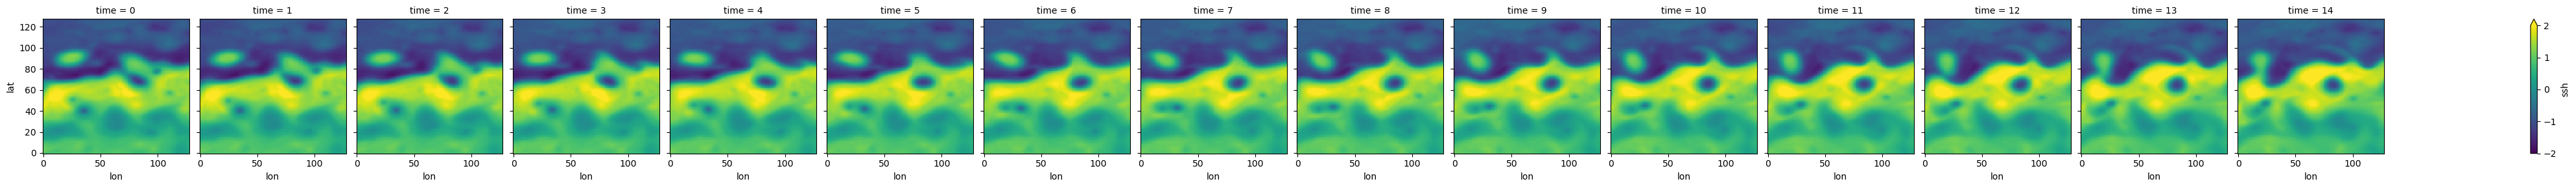

Résidu |x_hat - x| :


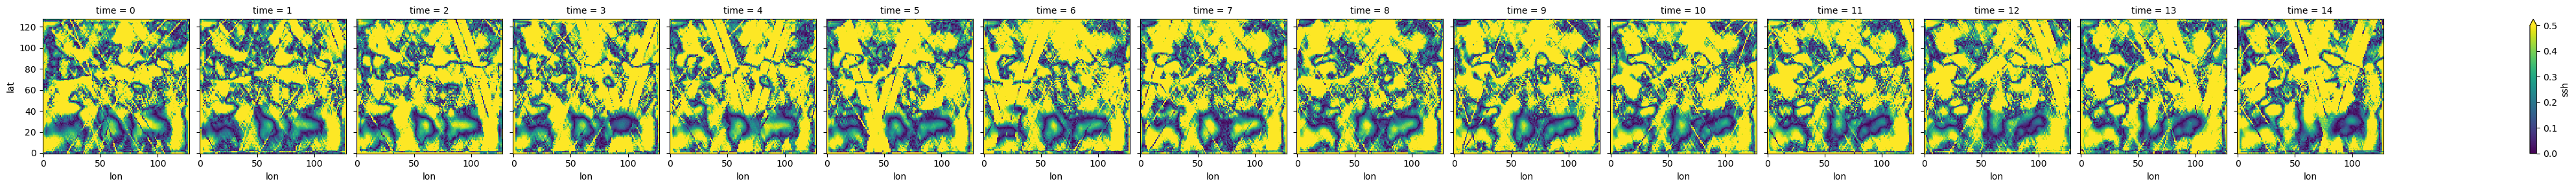

In [21]:
def plot_ssh(images: Tensor, vmin: float = -2., vmax: float = 2., cols: int = 15,
             title: str = "") -> None:
    """Affiche un champ SSH (C, H, W) comme grille de C cartes."""
    if title:
        print(title)
    arr = images.detach().float().cpu().numpy()
    if arr.shape[0] == 1:
        # xarray's col='time' faceting raises
        # "ValueError: IndexVariable objects must be 1-dimensional" when the
        # faceted dimension has size 1 (col_wrap=1 case) -- a single-panel
        # plain imshow sidesteps the FacetGrid machinery entirely for this
        # case instead of working around the xarray edge case.
        fig, ax = plt.subplots(figsize=(4, 4))
        im = ax.imshow(arr[0], origin='lower', vmin=vmin, vmax=vmax, cmap='RdBu_r')
        fig.colorbar(im, ax=ax)
        plt.show()
        return
    xr.Dataset(
        data_vars={'ssh': (('time', 'lat', 'lon'), arr)},
        coords={
            'time': np.arange(images.shape[0]),
            'lon':  np.arange(images.shape[2]),
            'lat':  np.arange(images.shape[1]),
        },
    ).ssh.plot(col='time', col_wrap=cols, vmin=vmin, vmax=vmax)
    plt.show()


# ---- Batch de test ----
seed_everything(42)
batch  = next(iter(datamodule.test_dataloader()))

y      = batch.input.to(device=device, dtype=dtype)
x_true = batch.tgt  .to(device=device, dtype=dtype)

mask     = y.isfinite().to(dtype)
y_filled = y.nan_to_num(0.0)

with torch.no_grad():
    iterates = solver(y_filled, mask, return_all_iterates=True)

x_hat = iterates[-1].detach()

# ---- Métriques globales ----
# Masked: a single NaN anywhere in x_hat/x_true would otherwise silently turn
# the whole RMSE into NaN. Also reports the NaN fraction directly, so a NaN
# solver output (e.g. an undertrained/unstable checkpoint) is diagnosed
# immediately instead of just printing "nan" with no further information.
_err_sq   = (x_hat - x_true).pow(2)
_bad_frac = (~torch.isfinite(_err_sq)).float().mean().item()
if _bad_frac > 0:
    print(f"⚠️  {_bad_frac*100:.2f}% non-finite values in (x_hat - x_true) -- "
          f"likely an unstable/undertrained checkpoint (solver diverging)")
_valid_err = _err_sq[torch.isfinite(_err_sq)]
rmse = _valid_err.mean().sqrt().item() if _valid_err.numel() > 0 else float('nan')
print(f"RMSE (test batch, itéré final, masked) : {rmse:.4f}")

# ---- Visualisation — premier échantillon du batch ----
b = 0
plot_ssh(y_filled[b].cpu(), title="Observations y (NaN → 0) :")
plot_ssh(x_hat[b].cpu(),    title="Reconstruction 4DVarNet x_hat :")
plot_ssh(x_true[b].cpu(),   title="Vérité terrain x :")
plot_ssh((x_hat[b] - x_true[b]).abs().cpu(), vmin=0, vmax=0.5,
         title="Résidu |x_hat - x| :")


### Convergence du solveur — évolution de x_k

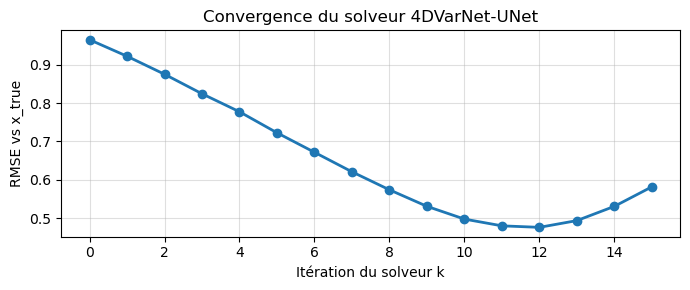

x_k (k=0) — pas de temps 0


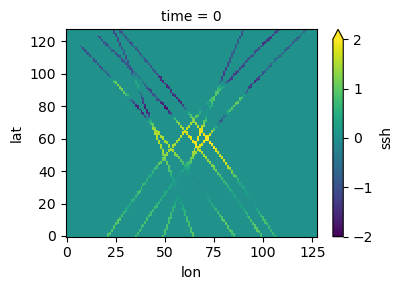

x_k (k=8) — pas de temps 0


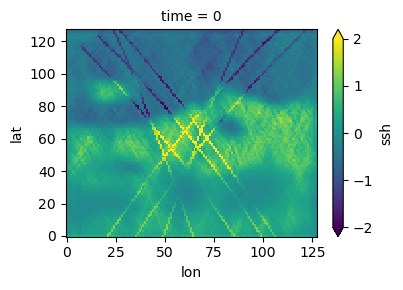

x_k (k=15) — pas de temps 0


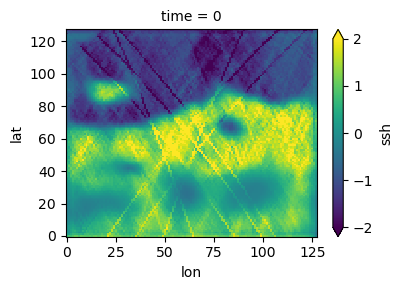

In [22]:
# RMSE de chaque itérée x_k par rapport à la vérité terrain
rmse_per_iter = [
    (xk[b:b+1].detach() - x_true[b:b+1]).pow(2).mean().sqrt().item()
    for xk in iterates
]

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(range(len(rmse_per_iter)), rmse_per_iter, marker='o', linewidth=2)
ax.set_xlabel("Itération du solveur k")
ax.set_ylabel("RMSE vs x_true")
ax.set_title("Convergence du solveur 4DVarNet-UNet")
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Montrer x_0, x_N//2, x_N  (premier pas de temps seulement pour la lisibilité)
for k_show in [0, len(iterates) // 2, len(iterates) - 1]:
    plot_ssh(
        iterates[k_show][b, :1].detach().cpu(),
        title=f"x_k (k={k_show}) — pas de temps 0",
        cols=1,
    )


### Métriques spectrales & tableau comparatif

In [ ]:
import sys
sys.path.append('../..')   # -> consistency/
from spectral_utils import radial_psd_2d, psd_spectral_score, resolved_scale
import numpy as np
import pandas as pd

DX_KM = 0.1 * 111   # 0.1 deg grid spacing -> km

# ── Full test-set evaluation ─────────────────────────────────────────────
# Loops over EVERY batch of datamodule.test_dataloader() (not just the first
# one used for the illustrative visualisation above), computing RMSE and the
# spectral resolved scale (lambda_x, via the SAME spectral_utils functions
# used by every other notebook in the suite -- previously this cell used its
# own ad-hoc PSD/lambda_x function, which computed a methodologically
# DIFFERENT quantity (raw PSD 50%-of-peak threshold on GT and reconstruction
# separately) than the rest of the suite (PSD-of-ERROR spectral score) --
# mixing the two within the same comparison table column would not be a
# valid apples-to-apples comparison). Deterministic method -- one solver pass
# per batch, no ensemble/CRPS.
_all = {'rmse': [], 'lambda_x': []}
_n_samples = 0

for _tb in datamodule.test_dataloader():
    _y_b      = _tb.input.to(device=device, dtype=dtype)
    _x_true_b = _tb.tgt.to(device=device, dtype=dtype)
    _mask_b     = _y_b.isfinite().to(dtype)
    _y_filled_b = _y_b.nan_to_num(0.0)
    with torch.no_grad():
        _iterates_b = solver(_y_filled_b, _mask_b, return_all_iterates=True)
    _x_hat_b = _iterates_b[-1].detach()

    for _bi in range(_x_true_b.shape[0]):
        _gt       = _x_true_b[_bi].float().cpu().numpy()
        _x_hat_np = _x_hat_b[_bi].float().cpu().numpy()

        _gt_std = np.nanstd(_gt)
        if _gt_std <= 0:
            continue
        _rmse_val = float(np.sqrt(np.nanmean((_x_hat_np - _gt) ** 2)))

        _gt_f   = np.nan_to_num(_gt,       nan=0.0)
        _pred_f = np.nan_to_num(_x_hat_np, nan=0.0)
        _lam_vals = []
        for _t in range(_gt_f.shape[0]):
            _wl, _, _, _spec = psd_spectral_score(_pred_f[_t], _gt_f[_t], dx=DX_KM)
            _lam = resolved_scale(_wl, _spec, threshold=0.5)
            if not np.isnan(_lam):
                _lam_vals.append(_lam)

        _all['rmse'].append(_rmse_val)
        if _lam_vals:
            _all['lambda_x'].append(float(np.mean(_lam_vals)))
        _n_samples += 1

print(f"Evaluated {_n_samples} test samples (full assimilation window each) across the full test set")

def _agg(vals):
    a = np.asarray(vals, dtype=float)
    a = a[~np.isnan(a)]
    return (float(np.mean(a)), float(np.std(a))) if len(a) else (np.nan, np.nan)

_rmse_m, _rmse_s = _agg(_all['rmse'])
_lam_m, _lam_s   = _agg(_all['lambda_x'])

row_4dv = {
    'Method'  : '4DVarNet (full test set)',
    'RMSE'    : f'{_rmse_m:.4f} $\\pm$ {_rmse_s:.4f}',
    'lambda_x': f'{_lam_m:.2f} $\\pm$ {_lam_s:.2f}' if not np.isnan(_lam_m) else '?',
}

df_metrics = pd.DataFrame([row_4dv]).set_index('Method')
print(f"## Performance Assessment -- 4DVarNet-UNet (full test set, n={_n_samples} samples)")
print()
display(df_metrics)

df_metrics

In [ ]:
# --- metrics serialization (patch_notebook_params.py) ---
import os
os.makedirs(os.path.dirname(METRICS_CSV) or '.', exist_ok=True)
_df_out = df_metrics.reset_index() if df_metrics.index.name == 'Method' else df_metrics
_df_out.to_csv(METRICS_CSV, index=False)
print(f'Metrics written to {METRICS_CSV}')
